# Matrix Structure and Transformations

This notebook accompanies Lecture 03, **Matrix Structure and Transformations**. It is a computational companion—not a second version of the lecture. Use the slides for the mathematical ideas and this notebook to inspect matrix patterns, verify factorizations, build standard matrices, and see how matrix multiplication changes geometry.

We use three complementary tools:

- **SymPy** for exact matrix identities and textbook-style output.
- **NumPy and SciPy** for floating-point factorization and triangular solves.
- **Matplotlib** for geometric experiments with transformations of the plane.

**Working habit:** predict each result before running the next code cell, then interpret what the computation reveals.

## Run the notebook locally or in Colab

Use Jupyter with the `qmcpy` environment, or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/03-matrix-structure-and-transformations.ipynb)

In Colab, run the setup cell below once and then continue in order. It installs the course's recorded `classlib` version. Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.linalg import lu, lu_factor, lu_solve, solve, solve_triangular
import sympy as sp
from sympy import Matrix

import classlib as cl
from classlib.nbviz import show_mat

%matplotlib inline

cl.nbviz.init(use_tex=False)
colors = cl.nbviz.TOL_BRIGHT
sp.init_printing()
np.set_printoptions(precision=6, suppress=True)

## 1. Inspect matrix patterns exactly

Diagonal, triangular, transposed, and symmetric structure can reveal behavior before a long calculation. Consider

$$
\mathsf{D}=
\begin{bmatrix}2&0&0\\0&-1&0\\0&0&1/2\end{bmatrix},\qquad
\mathsf{U}=
\begin{bmatrix}1&2&1\\0&2&2\\0&0&1\end{bmatrix},\qquad
\mathsf{S}=
\begin{bmatrix}4&-1&2\\-1&3&0\\2&0&5\end{bmatrix}.
$$

Before running the cell, predict how $\mathsf{D}$ acts on each coordinate, where the zeros of $\mathsf{U}^{-1}$ will lie, and whether $\mathsf{S}^{\mathsf T}$ will change $\mathsf{S}$.

D, U, S, and v:


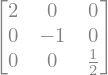

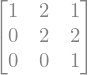

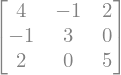

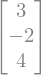

In [3]:
D = sp.diag(2, -1, sp.Rational(1, 2))
U_exact = Matrix([
    [1, 2, 1],
    [0, 2, 2],
    [0, 0, 1],
])
S = Matrix([
    [ 4, -1, 2],
    [-1,  3, 0],
    [ 2,  0, 5],
])
v_exact = Matrix([3, -2, 4])

print("D, U, S, and v:")
show_mat(D, U_exact, S, v_exact)

D v, U^{-1}, and U U^{-1}:


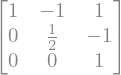

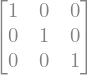

U^{-1} is upper triangular: True
S is symmetric: True
(A B)^T = B^T A^T: True


In [4]:
U_inverse = U_exact.inv()
entries_below_diagonal = [
    U_inverse[row, col]
    for row in range(U_inverse.rows)
    for col in range(U_inverse.cols)
    if row > col
]

print("D v, U^{-1}, and U U^{-1}:")
show_mat(D * v_exact, U_inverse, U_exact * U_inverse)
print("U^{-1} is upper triangular:", all(entry == 0 for entry in entries_below_diagonal))
print("S is symmetric:", S == S.T)

A_pattern = Matrix([[1, 2, 3], [4, 5, 6]])
B_pattern = Matrix([[2, 0], [1, -1], [3, 2]])
print("(A B)^T = B^T A^T:", (A_pattern * B_pattern).T == B_pattern.T * A_pattern.T)

## 2. Factor a matrix as $\mathsf{P}\mathsf{L}\mathsf{U}$

SciPy's `lu` function uses the convention

$$
\mathsf{A}=\mathsf{P}\mathsf{L}\mathsf{U},\qquad
\mathsf{P}^{\mathsf T}\mathsf{A}=\mathsf{L}\mathsf{U}.
$$

Here $\mathsf{P}^{\mathsf T}$ places the rows in elimination order, $\mathsf{L}$ stores the elimination multipliers, and $\mathsf{U}$ is upper triangular. Predict which row of $\mathsf{A}$ will supply the first pivot before running the factorization.

A, P, L, and U:


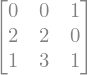

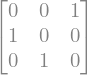

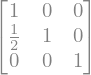

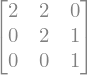

maximum error in A - P L U:    0.0
maximum error in P^T A - L U: 0.0


In [5]:
A_plu = np.array([
    [0.0, 0.0, 1.0],
    [2.0, 2.0, 0.0],
    [1.0, 3.0, 1.0],
])
P, L, U_plu = lu(A_plu)

def exact_display(array):
    """Convert small floating-point factors to simple exact display values."""
    return Matrix(np.asarray(array)).applyfunc(
        lambda value: sp.nsimplify(float(value), tolerance=1e-12, rational=True)
    )

print("A, P, L, and U:")
show_mat(exact_display(A_plu), exact_display(P), exact_display(L), exact_display(U_plu))
print("maximum error in A - P L U:   ", np.max(np.abs(A_plu - P @ L @ U_plu)))
print("maximum error in P^T A - L U:", np.max(np.abs(P.T @ A_plu - L @ U_plu)))

### Reuse the triangular factors

For several right-hand sides, factor $\mathsf{A}$ once. To solve $\mathsf{A}\mathsf{X}=\mathsf{B}$ from $\mathsf{A}=\mathsf{P}\mathsf{L}\mathsf{U}$, first solve

$$
\mathsf{L}\mathsf{Y}=\mathsf{P}^{\mathsf T}\mathsf{B},
$$

then solve $\mathsf{U}\mathsf{X}=\mathsf{Y}$. The two columns of $\mathsf{B}$ below represent two right-hand sides handled by the same factors.

solutions obtained from the reusable factors:


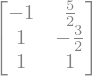

maximum residual in A X - B: 0.0
agreement with np.linalg.solve: True


In [6]:
B = np.array([
    [1.0,  1.0],
    [0.0,  2.0],
    [3.0, -1.0],
])

Y = solve_triangular(L, P.T @ B, lower=True, unit_diagonal=True)
X = solve_triangular(U_plu, Y, lower=False)
X_direct = np.linalg.solve(A_plu, B)

print("solutions obtained from the reusable factors:")
show_mat(exact_display(X))
print("maximum residual in A X - B:", np.max(np.abs(A_plu @ X - B)))
print("agreement with np.linalg.solve:", np.allclose(X, X_direct))

### Use SciPy's solve-oriented interface

The mathematical factors above make the structure visible. For computation, `lu_factor` stores the strict lower-triangular entries of $\mathsf{L}$ and the upper-triangular entries of $\mathsf{U}$ together in one array; the diagonal ones of $\mathsf{L}$ are implicit. Its vector `piv` records the row exchange made at each elimination step. It stores neither $\mathsf{L}^{-1}$ nor a permutation matrix.

The larger example below factors a $5\times5$ matrix once and solves for all three columns of $\mathsf{B}$ at the same time. `lu_solve` reads the packed data and pivot history, applies the row exchanges, and performs the forward and back substitutions. We unpack $\mathsf{L}$ and $\mathsf{U}$ only to inspect what SciPy stored.

A, recovered L, and recovered U:


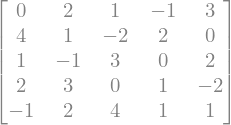

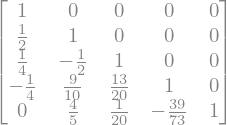

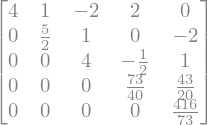

packed data (U on and above the diagonal, L below it):


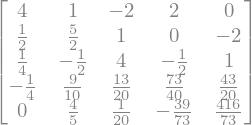

pivot swaps piv = [1 3 2 4 4]
rows of A in elimination order = [1 3 2 4 0]
maximum error in A[row_order, :] - L U: 2.220446049250313e-16
right-hand sides B and solutions X:


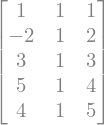

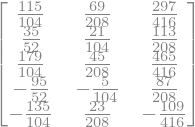

maximum residual in A X - B: 4.440892098500626e-16
agreement with explicit pivot, forward solve, and back solve: True
agreement with np.linalg.solve: True


In [7]:
A_large = np.array([
    [ 0.0,  2.0,  1.0, -1.0,  3.0],
    [ 4.0,  1.0, -2.0,  2.0,  0.0],
    [ 1.0, -1.0,  3.0,  0.0,  2.0],
    [ 2.0,  3.0,  0.0,  1.0, -2.0],
    [-1.0,  2.0,  4.0,  1.0,  1.0],
])
b_large = np.array([1.0, -2.0, 3.0, 5.0, 4.0])
B_large = np.column_stack((b_large, np.ones(5), np.arange(1.0, 6.0)))

lu_data, piv = lu_factor(A_large)
X_packed = lu_solve((lu_data, piv), B_large)

L_packed = np.tril(lu_data, k=-1) + np.eye(A_large.shape[0])
U_packed = np.triu(lu_data)
row_order = np.arange(A_large.shape[0])
for step, pivot_row in enumerate(piv):
    row_order[[step, pivot_row]] = row_order[[pivot_row, step]]
Y_steps = solve_triangular(
    L_packed, B_large[row_order, :], lower=True, unit_diagonal=True
)
X_steps = solve_triangular(U_packed, Y_steps, lower=False)

print("A, recovered L, and recovered U:")
show_mat(exact_display(A_large), exact_display(L_packed), exact_display(U_packed))
print("packed data (U on and above the diagonal, L below it):")
show_mat(exact_display(lu_data))
print("pivot swaps piv =", piv)
print("rows of A in elimination order =", row_order)
print("maximum error in A[row_order, :] - L U:",
      np.max(np.abs(A_large[row_order, :] - L_packed @ U_packed)))

print("right-hand sides B and solutions X:")
show_mat(exact_display(B_large), exact_display(X_packed))
print("maximum residual in A X - B:",
      np.max(np.abs(A_large @ X_packed - B_large)))
print("agreement with explicit pivot, forward solve, and back solve:",
      np.allclose(X_packed, X_steps))
print("agreement with np.linalg.solve:",
      np.allclose(X_packed, np.linalg.solve(A_large, B_large)))

### Compare fresh solves with saved PLU factors

For a dense $n\times n$ matrix, a fresh solve includes the $O(n^3)$ factorization. Once the packed PLU data and pivot history have been saved, `lu_solve` needs only the $O(n^2)$ permutation and triangular solves for each new right-hand side.

The benchmark below uses the median time over repeated calls. Exact times depend on the computer and its optimized linear-algebra library; the growth pattern is the important comparison. The dotted lines are theoretical $n^3$ and $n^2$ guides, not fitted timing models.

    n    fresh solve      saved PLU    speedup
   64       0.034 ms       0.006 ms       6.2x
  128       0.081 ms       0.010 ms       7.7x
  256       0.257 ms       0.028 ms       9.3x
  512       1.305 ms       0.105 ms      12.4x
 1024       5.090 ms       0.408 ms      12.5x
 2048      41.415 ms       1.849 ms      22.4x
 4096     221.657 ms       8.056 ms      27.5x
 8192    1059.249 ms      31.636 ms      33.5x
16384    5996.271 ms     203.454 ms      29.5x


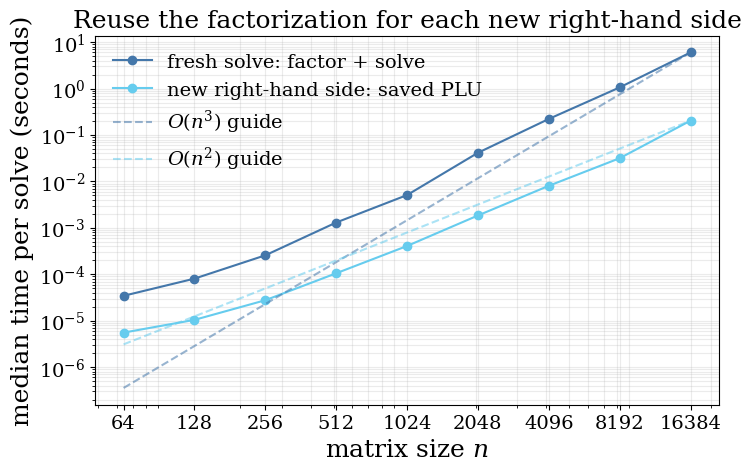

In [8]:
def median_call_time(operation, minimum_seconds=0.08, trials=5):
    """Return a stable per-call time and the batch size used."""
    repetitions = 1
    while repetitions < 4096:
        start = time.perf_counter()
        for _ in range(repetitions):
            operation()
        elapsed = time.perf_counter() - start
        if elapsed >= minimum_seconds:
            break
        repetitions *= 2

    samples = []
    for _ in range(trials):
        start = time.perf_counter()
        for _ in range(repetitions):
            operation()
        samples.append((time.perf_counter() - start) / repetitions)
    return float(np.median(samples)), repetitions


rng = np.random.default_rng(332)
matrix_sizes = np.array([64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384])
timing_rows = []

for n in matrix_sizes:
    A_timing = rng.standard_normal((n, n)) + n * np.eye(n)
    b_timing = rng.standard_normal(n)
    saved_plu = lu_factor(A_timing, check_finite=False)

    fresh_solve = lambda: solve(
        A_timing, b_timing, assume_a="gen", check_finite=False
    )
    reused_solve = lambda: lu_solve(
        saved_plu, b_timing, check_finite=False
    )

    fresh_solve()  # warm up the numerical library before timing
    reused_solution = reused_solve()
    assert np.allclose(A_timing @ reused_solution, b_timing)

    fresh_seconds, fresh_repetitions = median_call_time(fresh_solve)
    reused_seconds, reused_repetitions = median_call_time(reused_solve)
    timing_rows.append(
        (n, fresh_seconds, reused_seconds, fresh_seconds / reused_seconds)
    )

print(f"{'n':>5}  {'fresh solve':>13}  {'saved PLU':>13}  {'speedup':>9}")
for n, fresh_seconds, reused_seconds, speedup in timing_rows:
    print(
        f"{n:5d}  {1e3 * fresh_seconds:10.3f} ms  "
        f"{1e3 * reused_seconds:10.3f} ms  {speedup:8.1f}x"
    )

timings = np.asarray(timing_rows, dtype=float)
sizes = timings[:, 0]
fresh_times = timings[:, 1]
reused_times = timings[:, 2]

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
fresh_line, = ax.loglog(
    sizes, fresh_times, "o-", label="fresh solve: factor + solve"
)
reused_line, = ax.loglog(
    sizes, reused_times, "o-", label="new right-hand side: saved PLU"
)
ax.loglog(
    sizes, fresh_times[-1] * (sizes / sizes[-1]) ** 3, "--",
    color=fresh_line.get_color(), alpha=0.55, label=r"$O(n^3)$ guide",
)
ax.loglog(
    sizes, reused_times[-1] * (sizes / sizes[-1]) ** 2, "--",
    color=reused_line.get_color(), alpha=0.55, label=r"$O(n^2)$ guide",
)
ax.set_xticks(sizes)
ax.set_xticklabels([str(int(n)) for n in sizes])
ax.set_xlabel(r"matrix size $n$")
ax.set_ylabel("median time per solve (seconds)")
ax.set_title("Reuse the factorization for each new right-hand side")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

### Rectangular matrices use compact factors

For $\mathsf{A}\in\mathbb{R}^{m\times n}$, SciPy sets $k=\min(m,n)$ and returns factors with shapes

$$
\mathsf{P}:m\times m,\qquad
\mathsf{L}:m\times k,\qquad
\mathsf{U}:k\times n.
$$

The next cell checks one wide and one tall example.

In [9]:
rectangular_examples = {
    "wide": np.array([[2.0, 1.0, 3.0], [4.0, 3.0, 7.0]]),
    "tall": np.array([[2.0, 1.0], [4.0, 3.0], [1.0, 5.0], [3.0, 2.0]]),
}

for name, A_rect in rectangular_examples.items():
    P_rect, L_rect, U_rect = lu(A_rect)
    error = np.max(np.abs(A_rect - P_rect @ L_rect @ U_rect))
    print(f"\n{name.title()} example")
    print(
        f"A {A_rect.shape}, P {P_rect.shape}, L {L_rect.shape}, "
        f"U {U_rect.shape}, factorization error {error:.1e}"
    )
    for matrix_name, matrix in (
        ("A", A_rect),
        ("P", P_rect),
        ("L", L_rect),
        ("U", U_rect),
    ):
        print(f"{matrix_name} =\n{matrix}")


Wide example
A (2, 3), P (2, 2), L (2, 2), U (2, 3), factorization error 0.0e+00
A =
[[2. 1. 3.]
 [4. 3. 7.]]
P =
[[0. 1.]
 [1. 0.]]
L =
[[1.  0. ]
 [0.5 1. ]]
U =
[[ 4.   3.   7. ]
 [ 0.  -0.5 -0.5]]

Tall example
A (4, 2), P (4, 4), L (4, 2), U (2, 2), factorization error 0.0e+00
A =
[[2. 1.]
 [4. 3.]
 [1. 5.]
 [3. 2.]]
P =
[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
L =
[[ 1.        0.      ]
 [ 0.25      1.      ]
 [ 0.5      -0.117647]
 [ 0.75     -0.058824]]
U =
[[4.   3.  ]
 [0.   4.25]]


## 3. Build a standard matrix from basis images

### Construct the columns

Let $T:\mathbb{R}^2\to\mathbb{R}^3$ be

$$
T(x_1,x_2)=(x_1+2x_2,\ 3x_1-x_2,\ -x_1+x_2).
$$

The columns of the standard matrix are $T(\boldsymbol{e}_1)$ and $T(\boldsymbol{e}_2)$. Predict those two columns before asking Python to build them.

T(e1), T(e2), and the standard matrix A:


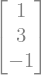

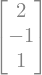

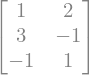

matrix shape for R^2 -> R^3: (3, 2)


In [10]:
def T(vector):
    x1, x2 = np.asarray(vector)
    return np.array([x1 + 2 * x2, 3 * x1 - x2, -x1 + x2])

standard_basis = np.eye(2, dtype=int)
basis_images = [T(standard_basis[:, j]) for j in range(2)]
A_standard = np.column_stack(basis_images)

print("T(e1), T(e2), and the standard matrix A:")
show_mat(basis_images[0], basis_images[1], A_standard)
print("matrix shape for R^2 -> R^3:", A_standard.shape)

### Test the action and linearity

Every vector $\boldsymbol{x}=x_1\boldsymbol{e}_1+x_2\boldsymbol{e}_2$ must satisfy

$$
T(\boldsymbol{x})=x_1T(\boldsymbol{e}_1)+x_2T(\boldsymbol{e}_2)=\mathsf{A}\boldsymbol{x}.
$$

A few computational checks can find an error, but they do not replace the algebraic argument that this equality holds for every input.

In [11]:
x_test = np.array([2, -1])
u = np.array([1, 2])
v = np.array([-2, 3])
a, b = 3, -2

print("T(x) = A x:", np.array_equal(T(x_test), A_standard @ x_test))
print("T(a u + b v) = a T(u) + b T(v):",
      np.array_equal(T(a * u + b * v), a * T(u) + b * T(v)))

shift = np.array([1, -2, 1])
def translated_map(vector):
    return T(vector) + shift

print("a translated map sends 0 to:", translated_map(np.zeros(2, dtype=int)))
print("therefore this translated map is linear:",
      np.array_equal(translated_map(np.zeros(2, dtype=int)), np.zeros(3, dtype=int)))

T(x) = A x: True
T(a u + b v) = a T(u) + b T(v): True
a translated map sends 0 to: [ 1 -2  1]
therefore this translated map is linear: False


## 4. See geometry through a matrix action

We compare four operators on $\mathbb{R}^2$:

- the identity,
- reflection across $x_2=x_1$,
- projection onto the $x_1$-axis, and
- counterclockwise rotation through $90^\circ$.

Before plotting, predict the image of each basis vector and of $\boldsymbol{v}=(2,1)^{\mathsf T}$. Which action loses information?

v, H v, Q v, and R90 v:


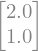

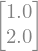

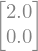

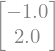

H H = I: True
Q Q = Q: True
R90^T R90 = I: True


In [12]:
I2 = np.eye(2)
H = np.array([[0.0, 1.0], [1.0, 0.0]])
Q = np.array([[1.0, 0.0], [0.0, 0.0]])
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])
v_geometry = np.array([2.0, 1.0])

print("v, H v, Q v, and R90 v:")
show_mat(v_geometry, H @ v_geometry, Q @ v_geometry, R90 @ v_geometry)
print("H H = I:", np.allclose(H @ H, I2))
print("Q Q = Q:", np.allclose(Q @ Q, Q))
print("R90^T R90 = I:", np.allclose(R90.T @ R90, I2))

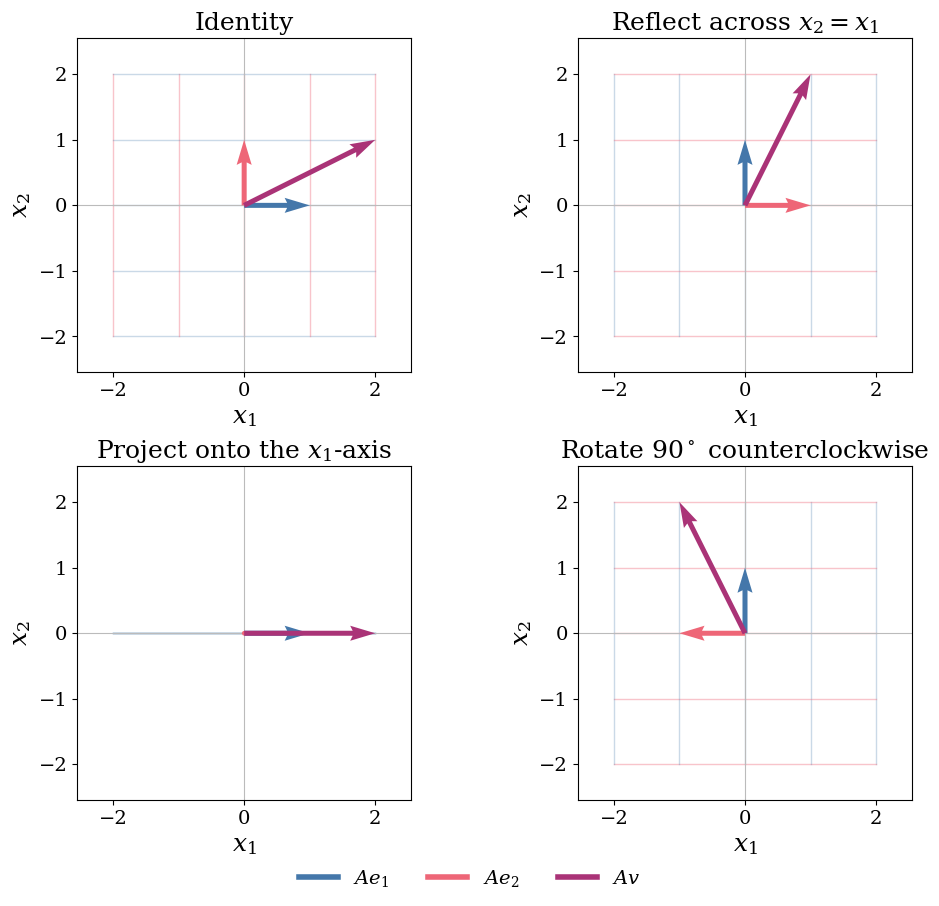

In [13]:
def plot_matrix_action(A, title, ax, extent=2):
    """Plot the transformed coordinate grid, basis vectors, and v=(2,1)."""
    parameter = np.linspace(-extent, extent, 201)
    for level in np.arange(-extent, extent + 1):
        horizontal = np.vstack((parameter, np.full_like(parameter, level)))
        vertical = np.vstack((np.full_like(parameter, level), parameter))
        horizontal_image = A @ horizontal
        vertical_image = A @ vertical
        ax.plot(
            horizontal_image[0], horizontal_image[1],
            color=colors["blue"], linewidth=1.0, alpha=0.28,
        )
        ax.plot(
            vertical_image[0], vertical_image[1],
            color=colors["red"], linewidth=1.0, alpha=0.38,
        )

    vectors = np.column_stack((A @ np.array([1.0, 0.0]),
                               A @ np.array([0.0, 1.0]),
                               A @ v_geometry))
    ax.quiver(
        np.zeros(3), np.zeros(3), vectors[0], vectors[1],
        color=[colors["blue"], colors["red"], colors["purple"]],
        angles="xy", scale_units="xy", scale=1, width=0.015, zorder=5,
    )
    ax.axhline(0, color=colors["grey"], linewidth=0.8)
    ax.axvline(0, color=colors["grey"], linewidth=0.8)
    ax.set(
        title=title, xlabel=r"$x_1$", ylabel=r"$x_2$",
        xlim=(-2.55, 2.55), ylim=(-2.55, 2.55),
    )
    ax.set_aspect("equal")

actions = [
    (I2, "Identity"),
    (H, r"Reflect across $x_2=x_1$"),
    (Q, r"Project onto the $x_1$-axis"),
    (R90, r"Rotate $90^\circ$ counterclockwise"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
for (action, title), ax in zip(actions, axes.ravel()):
    plot_matrix_action(action, title, ax)

legend_items = [
    Line2D([0], [0], color=colors["blue"], linewidth=4, label=r"$A e_1$"),
    Line2D([0], [0], color=colors["red"], linewidth=4, label=r"$A e_2$"),
    Line2D([0], [0], color=colors["purple"], linewidth=4, label=r"$A v$"),
]
fig.legend(handles=legend_items, loc="outside lower center", ncol=3)
plt.show()

Read the plots by following the two coordinate-line families and the basis arrows. Reflection and rotation rearrange the grid without collapsing it. Projection sends every vertical line to one point on the $x_1$-axis and every horizontal line to that same axis: an entire direction has disappeared.

## 5. Compose transformations in the correct order

### Order changes the action

Let $\mathsf{R}$ rotate $90^\circ$ counterclockwise and let $\mathsf{Q}$ project onto the $x_1$-axis. The rightmost matrix acts first:

$$
\mathsf{Q}\mathsf{R}\boldsymbol{v}=\mathsf{Q}(\mathsf{R}\boldsymbol{v}),\qquad
\mathsf{R}\mathsf{Q}\boldsymbol{v}=\mathsf{R}(\mathsf{Q}\boldsymbol{v}).
$$

Predict both results for $\boldsymbol{v}=(2,1)^{\mathsf T}$.

Q R, R Q, (Q R)v, and (R Q)v:


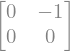

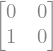

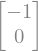

Q R = R Q: False


In [14]:
R_exact = Matrix([[0, -1], [1, 0]])
Q_exact = Matrix([[1, 0], [0, 0]])
v_composition = Matrix([2, 1])

print("Q R, R Q, (Q R)v, and (R Q)v:")
show_mat(
    Q_exact * R_exact,
    R_exact * Q_exact,
    Q_exact * R_exact * v_composition,
    R_exact * Q_exact * v_composition,
)
print("Q R = R Q:", Q_exact * R_exact == R_exact * Q_exact)

### Undo a composition in reverse order

Reflection $\mathsf{H}$ is its own inverse, and rotation $\mathsf{R}$ is undone by $\mathsf{R}^{\mathsf T}$. Therefore the inverse of $\mathsf{H}\mathsf{R}$ must be $\mathsf{R}^{\mathsf T}\mathsf{H}$. Projection has no inverse because it sends a nonzero direction to zero.

H R, its proposed inverse, and their product:


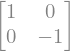

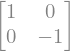

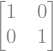

the composition was undone: True
Q sends the nonzero vector e2 to:


Q(v + 5 e2) = Qv: True


In [15]:
H_exact = Matrix([[0, 1], [1, 0]])
I_exact = sp.eye(2)
composite = H_exact * R_exact
undo_composite = R_exact.T * H_exact
lost_direction = Matrix([0, 1])

print("H R, its proposed inverse, and their product:")
show_mat(composite, undo_composite, undo_composite * composite)
print("the composition was undone:", undo_composite * composite == I_exact)
print("Q sends the nonzero vector e2 to:")
show_mat(Q_exact * lost_direction)
print("Q(v + 5 e2) = Qv:",
      Q_exact * (v_composition + 5 * lost_direction) == Q_exact * v_composition)

## 6. Experiments

Try these after the main notebook runs successfully:

1. Change `theta_degrees` below. Predict the two basis images and the transformed grid before running the cell.
2. Replace the diagonal stretch in `A_experiment` by a reflection or a shear. Which factor acts first?
3. Define a new linear map by specifying the images of $\boldsymbol{e}_1$ and $\boldsymbol{e}_2$, build its standard matrix, and plot its action.
4. Change the two columns of `B` in Section 2 and reuse the existing $\mathsf{P}$, $\mathsf{L}$, and $\mathsf{U}$ factors. Check every new solution with a residual.
5. Find two different vectors with the same image under $\mathsf{Q}$. Explain why this rules out an inverse.

The rightmost diagonal matrix stretches first; the rotation acts second.


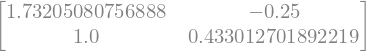

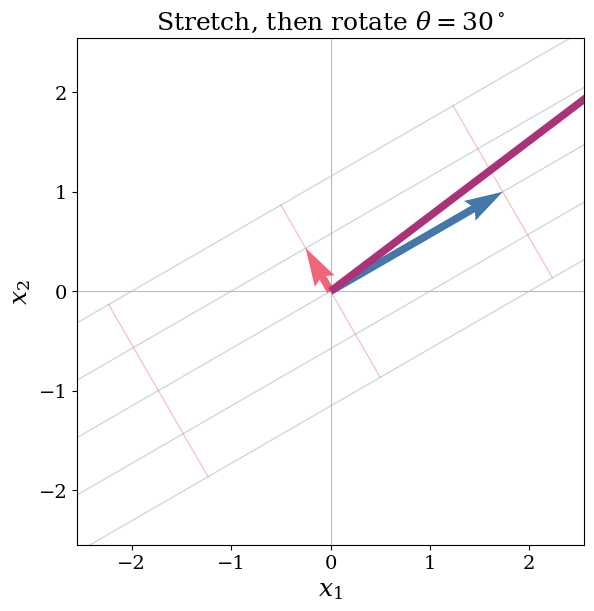

In [16]:
# EDITABLE INPUT: change the angle or the two coordinate scale factors.
theta_degrees = 30
scale_factors = np.array([2.0, 0.5])

theta = np.deg2rad(theta_degrees)
R_theta = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])
A_experiment = R_theta @ np.diag(scale_factors)

print("The rightmost diagonal matrix stretches first; the rotation acts second.")
show_mat(A_experiment)
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
plot_matrix_action(
    A_experiment,
    rf"Stretch, then rotate $\theta={theta_degrees}^\circ$",
    ax,
)
plt.show()

## 7. What to retain

- Matrix patterns such as diagonal, triangular, and symmetric structure reveal behavior before a general calculation.
- In SciPy's convention, $\mathsf{A}=\mathsf{P}\mathsf{L}\mathsf{U}$ and $\mathsf{P}^{\mathsf T}\mathsf{A}=\mathsf{L}\mathsf{U}$.
- For dense square systems, the first solve costs $O(n^3)$ operations; each new right-hand side costs $O(n^2)$ when `lu_solve` reuses SciPy's packed PLU data.
- The images of the standard basis vectors are the columns of a linear transformation's standard matrix.
- Reflection and rotation preserve information; projection collapses a direction.
- In a product, the rightmost transformation acts first, and inverses undo actions in reverse order.

Use computation to expose structure, test predictions, and connect algebra with geometry—not to replace the reasoning in the slides.

In [17]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 1 min 21.5 sec.
